In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal

In [2]:
class State(TypedDict):
    seed: str


graph_builder = StateGraph(State)

In [3]:
def node_one(state: State):
    print("node_one ->", state)
    return {}


def node_two(state: State):
    print("node_two ->", state)
    return {}


def node_three(state: State):
    print("node_three ->", state)
    return {}


def node_four(state: State):
    print("node_four ->", state)
    return {}

In [4]:
# add node
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)


# def routing_fnc(state: State) -> Literal["node_three", "node_four"]:
#     if state["seed"] % 2 == 0:
#         return "node_three"
#     return "node_four"


def routing_fnc(state: State):
    return state["seed"] % 2 == 0


# graph
graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
# graph_builder.add_conditional_edges("node_two", routing_fnc)
graph_builder.add_conditional_edges(
    "node_two",
    routing_fnc,
    {
        True: "node_three",
        False: "node_four",
        "hello": END,
    },
)
graph_builder.add_edge("node_four", END)

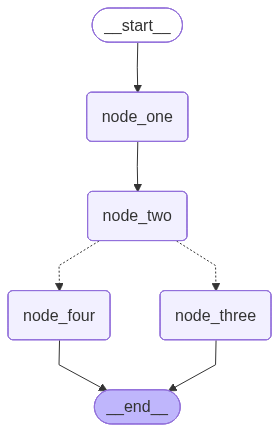

In [5]:
graph = graph_builder.compile()

graph

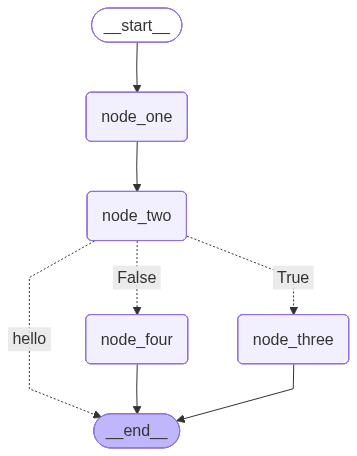

In [5]:
graph = graph_builder.compile()

graph

In [ ]:
graph.invoke({"seed": 1})

node_one -> {'seed': 1}
node_two -> {'seed': 1}
node_four -> {'seed': 1}


{'seed': 1}

In [6]:
graph.invoke({"seed": 2})

node_one -> {'seed': 2}
node_two -> {'seed': 2}
node_three -> {'seed': 2}


{'seed': 2}